# Smart Used Car Price Prediction System
## Phase 1: Data Loading and Initial Exploration
In this section, we import the necessary libraries and load the dataset to understand its structure and initial features.


In [29]:
# Import core libraries for data manipulation and analysis
import pandas as pd
import numpy as np

# Load the dataset
# Ensure the CSV file is in the same directory or provide the correct path
df = pd.read_csv('car data.csv')

# Display the first 5 rows to verify successful loading and preview the data
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 1.1 Data Structure and Missing Values Check
We use `.info()` to inspect the data types of each column and check for any missing (null) values that require handling during preprocessing.

In [30]:
# Check data types, number of entries, and look for missing values
print("Dataset Information:")
df.info()

# Print the shape of the dataset (Rows, Columns)
print(f"\nDataset Shape: {df.shape}")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Dataset Shape: (301, 9)


## 1.2 Statistical Summary of Numerical Features
We look at the statistical summary (mean, min, max, standard deviation) to understand the distribution of numerical features like price and mileage, and to detect any potential outliers.

In [31]:
# Generate descriptive statistics for numerical columns
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## 1.3 Analysis of Categorical Features
We explore the unique categories within our textual columns (Fuel_Type, Seller_Type, Transmission) to plan our encoding strategy for the machine learning model.

In [32]:
# Generate descriptive statistics for categorical (object) columns
df.describe(include='O')

,Car_Name,Fuel_Type,Seller_Type,Transmission
count,301,301,301,301
unique,98,3,2,2
top,city,Petrol,Dealer,Manual
freq,26,239,195,261


# Phase 2: Exploratory Data Analysis (EDA)
In this phase, we visualize the data to understand the distributions of features and their relationships with the target variable (`Selling_Price`).

## 2.1 Distribution of the Target Variable (Selling Price)
We visualize the distribution of `Selling_Price` to check for skewness and understand the range of prices in our dataset.

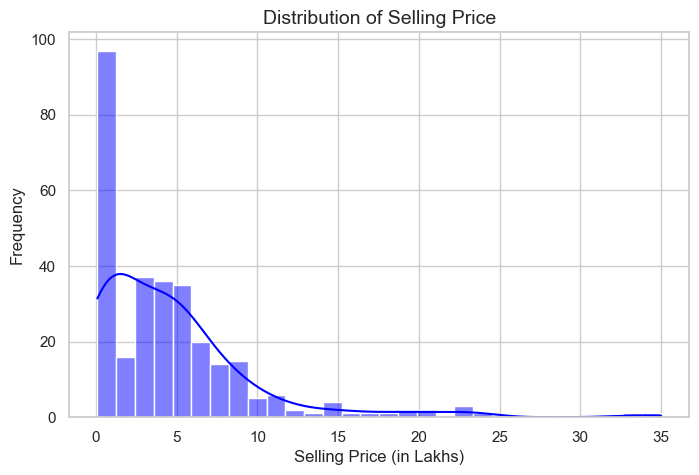

In [33]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for cleaner plots
sns.set_theme(style="whitegrid")

# Plot the distribution of Selling_Price
plt.figure(figsize=(8, 5))
sns.histplot(df['Selling_Price'], kde=True, color='blue', bins=30)
plt.title('Distribution of Selling Price', fontsize=14)
plt.xlabel('Selling Price (in Lakhs)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

## 2.2 Correlation Analysis
We generate a correlation matrix and visualize it using a Heatmap to identify the linear relationships between numerical features. This helps us see which variables most strongly influence the car price.

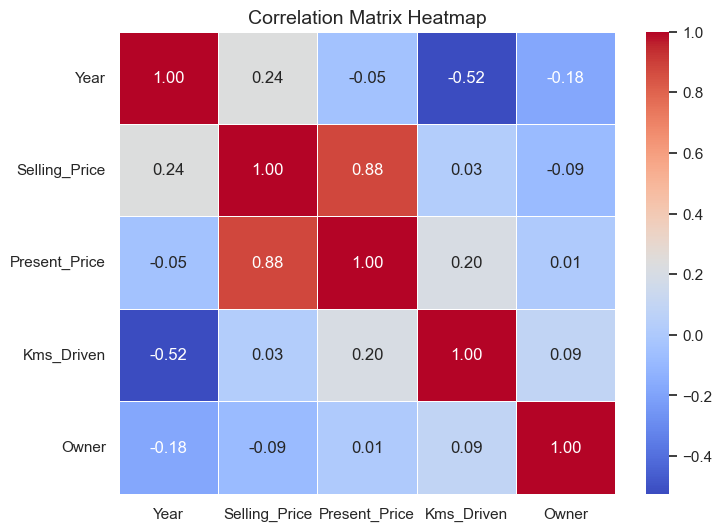

In [34]:
# Select only numerical columns for correlation calculation
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate the correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=14)
plt.show()

## 2.3 Feature Relationships: Selling Price vs. Present Price
Since `Present_Price` typically shows the strongest correlation with `Selling_Price`, we plot a scatter plot to visualize this relationship and identify any potential anomalies or patterns.

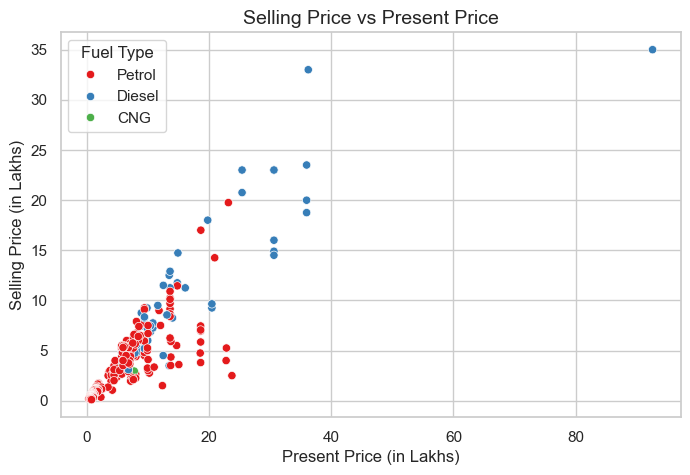

In [35]:
# Plot Scatter Plot between Present Price and Selling Price
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df, hue='Fuel_Type', palette='Set1')
plt.title('Selling Price vs Present Price', fontsize=14)
# (in Lakhs) is just the unit used in this Indian dataset (Cardekho)
plt.xlabel('Present Price (in Lakhs)', fontsize=12)
plt.ylabel('Selling Price (in Lakhs)', fontsize=12)
plt.legend(title='Fuel Type')
plt.show()

# Phase 3: Data Preprocessing & Feature Engineering
In this phase, we prepare the data for our Machine Learning model. This includes:
1. Creating a new feature `Car_Age` derived from the `Year` column (Current Year 2026 - Manufacturing Year).
2. Dropping irrelevant columns like `Car_Name` and the original `Year`.
3. Converting categorical text columns into numerical values using One-Hot Encoding.

In [36]:
# 1. Create 'Car_Age' feature to represent how old the car is in 2026
df['Car_Age'] = 2026 - df['Year']

# Drop 'Year' as it's now replaced by 'Car_Age', and 'Car_Name' because it has too many unique values
df.drop(['Year', 'Car_Name'], axis=1, inplace=True)

# 2. Convert categorical text columns (Fuel_Type, Seller_Type, Transmission) into numerical dummy variables
# drop_first=True is used to avoid the dummy variable trap (multicollinearity)
df_processed = pd.get_dummies(df, drop_first=True)

# Display the first 5 rows of the processed dataframe to verify changes
print("Processed Dataset Preview:")
df_processed.head()

Processed Dataset Preview:


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


## 3.1 Feature Engineering and Explicit Mapping
We will explicitly map binary categorical features (`Transmission` and `Seller_Type`) to 0 and 1. Then, we will create the `Car_Age` feature and drop unnecessary columns.

In [48]:
# Reload data to start fresh
df = pd.read_csv('car data.csv')

# 1. Extract the first word to get the raw model name
df['Model_Raw'] = df['Car_Name'].apply(lambda x: x.split()[0].lower())

# 2. Smart Mapping Engine: Group models into their Parent Brands
def map_to_parent_brand(model):
    if model in ['swift', 'dzire', 'alto', 'ritz', 'sx4', 'ciaz', 'ertiga', 'wagon']:
        return 'suzuki'
    elif model in ['corolla', 'fortuner', 'innova', 'etios']:
        return 'toyota'
    elif model in ['city', 'brio', 'amaze', 'jazz']:
        return 'honda'
    elif model in ['verna', 'i20', 'grand', 'i10', 'xcent', 'eon', 'creta']:
        return 'hyundai'
    else:
        return 'other'

# Apply the mapping to create a clean 'Brand' column
df['Brand'] = df['Model_Raw'].apply(map_to_parent_brand)

# 3. Explicit Mapping for Binary Categorical Features
df['Transmission'] = df['Transmission'].map({'Manual': 1, 'Automatic': 0})
df['Seller_Type'] = df['Seller_Type'].map({'Dealer': 1, 'Individual': 0})

# 4. Feature Engineering: Calculate Car Age
df['Car_Age'] = 2026 - df['Year']

# 5. Drop columns that are no longer needed (including the raw model name)
df.drop(['Year', 'Car_Name', 'Model_Raw'], axis=1, inplace=True)

# 6. Apply One-Hot Encoding on Fuel_Type and the new Parent Brand column
df_encoded = pd.get_dummies(df, columns=['Fuel_Type', 'Brand'], drop_first=True)

# Show the new beautiful structure
df_encoded.head()

,Selling_Price,Present_Price,Kms_Driven,Seller_Type,Transmission,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Brand_hyundai,Brand_other,Brand_suzuki,Brand_toyota
0,3.35,5.59,27000,1,1,0,12,False,True,False,False,True,False
1,4.75,9.54,43000,1,1,0,13,True,False,False,False,True,False
2,7.25,9.85,6900,1,1,0,9,False,True,False,False,True,False
3,2.85,4.15,5200,1,1,0,15,False,True,False,False,True,False
4,4.60,6.87,42450,1,1,0,12,True,False,False,False,True,False


## 3.2 Outlier Detection and Removal (IQR Method)
We fix the logical conditions using proper parentheses to filter out outliers. We then visualize the 'Selling_Price' before and after cleaning using Boxplots to verify the removal of extreme values.

Dataset shape BEFORE outlier removal: (301, 13)
Dataset shape AFTER outlier removal: (278, 13)


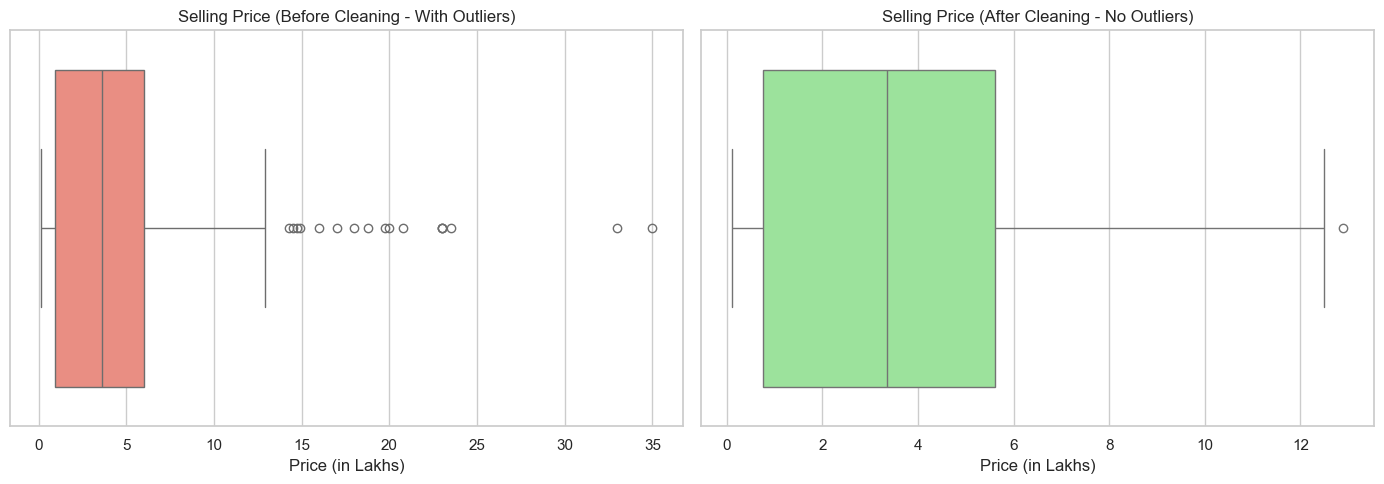

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Corrected function with proper parentheses around BOTH conditions
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # FIX: Parentheses added around (data[column] <= upper_bound)
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Apply the corrected function
df_clean = remove_outliers_iqr(df_encoded, 'Selling_Price')
df_clean = remove_outliers_iqr(df_clean, 'Kms_Driven')

# Print the new shapes to verify data reduction
print(f"Dataset shape BEFORE outlier removal: {df_encoded.shape}")
print(f"Dataset shape AFTER outlier removal: {df_clean.shape}")

# 2. Plotting Boxplots (Before vs After) to show the doctor your work
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Before Cleaning
sns.boxplot(ax=axes[0], x=df_encoded['Selling_Price'], color='salmon')
axes[0].set_title('Selling Price (Before Cleaning - With Outliers)', fontsize=12)
axes[0].set_xlabel('Price (in Lakhs)')

# Plot After Cleaning
sns.boxplot(ax=axes[1], x=df_clean['Selling_Price'], color='lightgreen')
axes[1].set_title('Selling Price (After Cleaning - No Outliers)', fontsize=12)
axes[1].set_xlabel('Price (in Lakhs)')

plt.tight_layout()
plt.show()

# Phase 4: Model Experimentation & Hyperparameter Tuning

## 4.1 Train-Test Split
We split our cleaned dataset (`df_clean`) into features (`X`) and the target variable (`y`) using an 80-20 ratio.

In [50]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_clean.drop('Selling_Price', axis=1)
y = df_clean['Selling_Price']

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 222, Test size: 56


## 4.2 Training Multiple Regression Models
We will train four different algorithms with their default parameters to compare their base performance using Mean Absolute Error (MAE) and R-squared ($R^2$) Score.

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Initialize the models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# Dictionary to store results
results = []

# Loop through each model, train, predict, and evaluate
for name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)
    # Make predictions
    predictions = model.predict(X_test)
    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    # Append to results list
    results.append({
        'Model': name,
        'MAE': round(mae, 3),
        'R2 Score (%)': round(r2 * 100, 2)
    })

# Convert results to a DataFrame for a clean summary table
df_results = pd.DataFrame(results)
df_results

,Model,MAE,R2 Score (%)
0,Linear Regression,0.992,79.97
1,Decision Tree,0.782,82.56
2,Random Forest,0.573,91.96
3,Gradient Boosting,0.517,93.90


## 4.3 Hyperparameter Tuning via GridSearchCV
To maximize the performance of our best model (Random Forest), we perform a Grid Search over a defined parameter grid to find the optimal combination of hyperparameters.

In [52]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit Grid Search on training data
print("Starting Grid Search Tuning...")
grid_search.fit(X_train, y_train)

# Print the best parameters found
print("\nBest Parameters Found:")
print(grid_search.best_params_)

# Evaluate the tuned model on test data
best_rf_model = grid_search.best_estimator_
tuned_predictions = best_rf_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_r2 = r2_score(y_test, tuned_predictions)

print(f"\nTuned Random Forest - MAE: {tuned_mae:.3f}")
print(f"Tuned Random Forest - R2 Score: {tuned_r2 * 100:.2f}%")

Starting Grid Search Tuning...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters Found:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}

Tuned Random Forest - MAE: 0.586
Tuned Random Forest - R2 Score: 91.59%


## 4.4 Final Model Comparison Visualization
We append the optimized (Tuned) Random Forest model to our summary table and visualize the $R^2$ Scores of all tested models to present to the discussion committee.

Final Comparison Table:
                 Model    MAE  R2 Score (%)
0    Linear Regression  0.992         79.97
1        Decision Tree  0.782         82.56
2        Random Forest  0.573         91.96
3    Gradient Boosting  0.517         93.90
4  Tuned Random Forest  0.586         91.59


C:\Users\LapStore\AppData\Local\Temp\ipykernel_5684\393258736.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2 Score (%)', y='Model', data=df_results.sort_values(by='R2 Score (%)', ascending=False), palette='viridis')


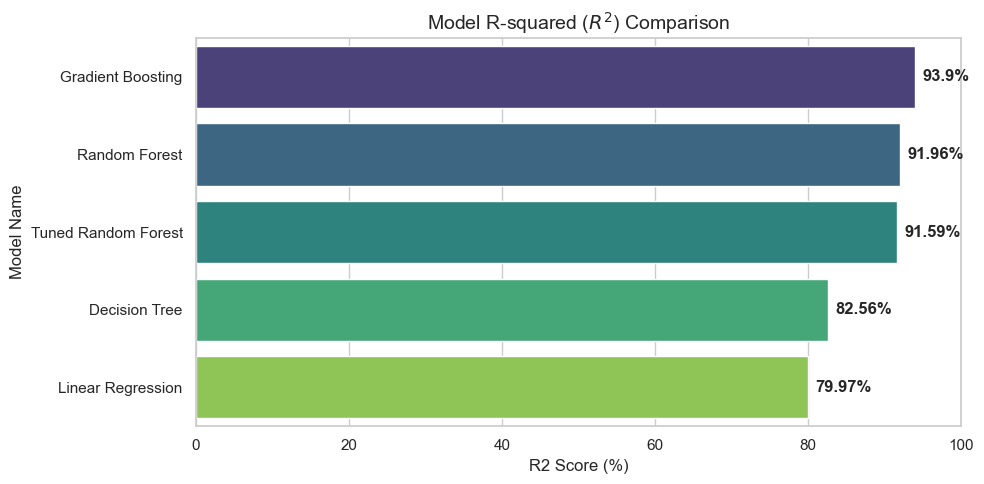

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add the tuned model results to our DataFrame
df_results.loc[len(df_results)] = {
    'Model': 'Tuned Random Forest',
    'MAE': round(tuned_mae, 3),
    'R2 Score (%)': round(tuned_r2 * 100, 2)
}

print("Final Comparison Table:")
print(df_results)

# Plotting the R2 Scores
plt.figure(figsize=(10, 5))
sns.barplot(x='R2 Score (%)', y='Model', data=df_results.sort_values(by='R2 Score (%)', ascending=False), palette='viridis')
plt.title('Model R-squared ($R^2$) Comparison', fontsize=14)
plt.xlabel('R2 Score (%)', fontsize=12)
plt.ylabel('Model Name', fontsize=12)
plt.xlim(0, 100)

# Add value labels on the bars
for index, value in enumerate(df_results.sort_values(by='R2 Score (%)', ascending=False)['R2 Score (%)']):
    plt.text(value + 1, index, f"{value}%", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Phase 5: Production Model Serialization
We save our best performing, fine-tuned model along with the feature column names to disk, preparing it for deployment in the Streamlit web application.

In [54]:
import joblib

# Save the best model from Grid Search
joblib.dump(best_rf_model, 'car_price_rf_model.pkl')

# Save columns list
model_columns = list(X.columns)
joblib.dump(model_columns, 'model_columns.pkl')

print("Perfect: Optimized model and features successfully saved for Streamlit!")

Perfect: Optimized model and features successfully saved for Streamlit!


In [55]:
# Save the winning Gradient Boosting model
joblib.dump(models['Gradient Boosting'], 'car_price_best_model.pkl')
print("Saved Gradient Boosting as the final production model!")

Saved Gradient Boosting as the final production model!
